# MACRO LANDSCAPE: US Yield Curve - FRED Database

In [7]:
%matplotlib inline
import os
import io
import time
from datetime import date, datetime, timedelta
import scipy
from fredapi import Fred


# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#Import Model Packages 
from sklearn.decomposition import PCA


In [8]:
#Initiliase the Fred API
fred = Fred(api_key='eb7110d142550e5c11ff1d58efcface1')

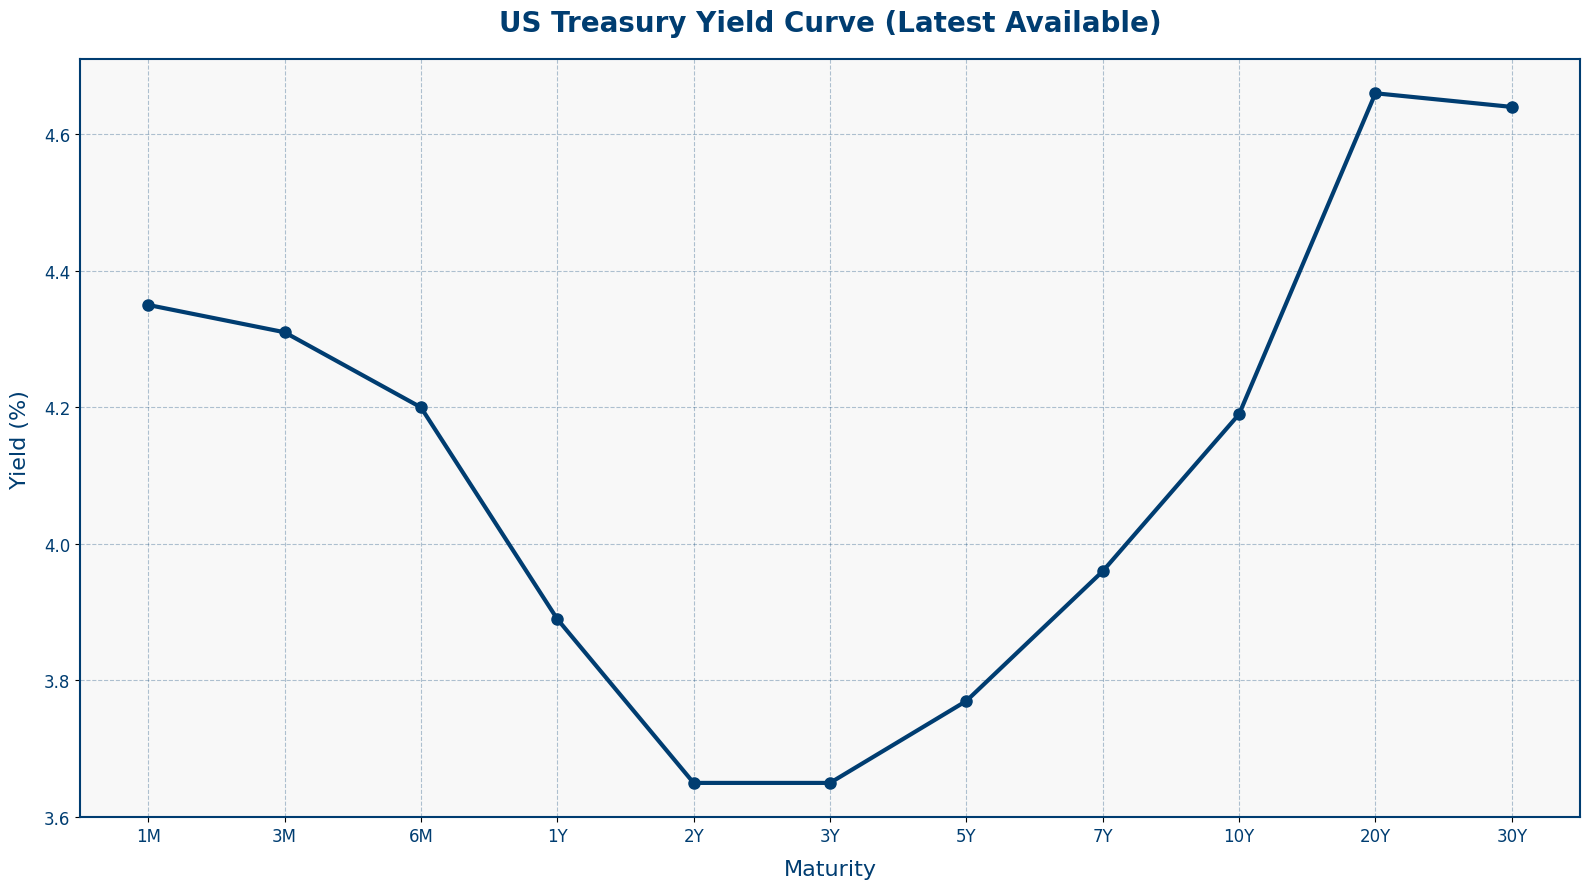

In [11]:
#Get tenors for the yield curve from FRED database
maturities = {
    '1M': 'DGS1MO',
    '3M': 'DGS3MO',
    '6M': 'DGS6MO',
    '1Y': 'DGS1',
    '2Y': 'DGS2',
    '3Y': 'DGS3',
    '5Y': 'DGS5',
    '7Y': 'DGS7',
    '10Y': 'DGS10',
    '20Y': 'DGS20',
    '30Y': 'DGS30',
}

end = pd.Timestamp.today()
start = end - pd.Timedelta(days=5)

# Retrieve latest yields
curve_data = {}
for label, code in maturities.items():
    series = fred.get_series(code, start, end).dropna()
    if not series.empty:
        curve_data[label] = series.iloc[-1]

curve_df = pd.Series(curve_data).astype(float)

# Sort by maturity
def maturity_to_months(label):
    if label.endswith("M"):
        return int(label[:-1])
    elif label.endswith("Y"):
        return int(label[:-1]) * 12
    return 999

curve_df = curve_df.sort_index(key=lambda x: x.map(maturity_to_months))

# Set McKinsey-style colors 
mckinsey_blue = '#003D71'
mckinsey_grid = '#003D71'
background_color = '#F8F8F8'

# Create the plot
plt.figure(figsize=(16, 9), facecolor='white')
plt.plot(curve_df.index, curve_df.values, 
         marker='o', 
         linewidth=3, 
         markersize=8, 
         color=mckinsey_blue)

# Formatting
plt.title('US Treasury Yield Curve (Latest Available)', 
          fontsize=20, 
          fontweight='bold', 
          pad=20, 
          color=mckinsey_blue)

plt.xlabel('Maturity', 
           fontsize=16, 
           color=mckinsey_blue, 
           labelpad=10)

plt.ylabel('Yield (%)', 
           fontsize=16, 
           color=mckinsey_blue, 
           labelpad=10)

# Customize ticks
plt.xticks(fontsize=12, color=mckinsey_blue)
plt.yticks(fontsize=12, color=mckinsey_blue)

# Customize grid
plt.grid(True, linestyle='--', alpha=0.3, color=mckinsey_grid)

# Customize spines
for spine in plt.gca().spines.values():
    spine.set_color(mckinsey_blue)
    spine.set_linewidth(1.5)

# Background color
plt.gca().set_facecolor(background_color)

# Final layout
plt.tight_layout()
plt.show()